In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("smartcart_customers.csv")

In [3]:
X = data.drop("ID", axis = 1)
X.isnull().sum()

Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [30]:
X["Income"] =X["Income"].fillna(X["Income"].median) 
X_clean["Income"] = pd.to_numeric(X_clean["Income"], errors="coerce")
X.isnull().sum()

Year_Birth               0
Education                0
Marital_Status           0
Income                   0
Kidhome                  0
Teenhome                 0
Dt_Customer              0
Recency                  0
MntWines                 0
MntFruits                0
MntMeatProducts          0
MntFishProducts          0
MntSweetProducts         0
MntGoldProds             0
NumDealsPurchases        0
NumWebPurchases          0
NumCatalogPurchases      0
NumStorePurchases        0
NumWebVisitsMonth        0
Complain                 0
Response                 0
age                      0
Coustomer Tenure Days    0
Total_spending           0
Total_childs             0
Living_With              0
dtype: int64

In [5]:
X["age"] = 2026- X["Year_Birth"]

X["Dt_Customer"] = pd.to_datetime(X["Dt_Customer"], dayfirst = True)
X["Coustomer Tenure Days"] = X["Dt_Customer"].max() -X["Dt_Customer"]


X["Total_spending"] = X["MntWines"] + X["MntGoldProds"] + X["MntFruits"] + X["MntMeatProducts"] + X["MntFishProducts"] + X["MntSweetProducts"]


X["Total_childs"] = X["Kidhome"] + X["Teenhome"]
X

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,age,Coustomer Tenure Days,Total_spending,Total_childs
0,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,...,8,10,4,7,0,1,69,663 days,1617,0
1,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,...,1,1,2,5,0,0,72,113 days,27,2
2,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,...,8,2,10,4,0,0,61,312 days,776,0
3,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,...,2,0,4,6,0,0,42,139 days,53,1
4,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,...,5,3,6,5,0,0,45,161 days,422,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,61223.0,0,1,2013-06-13,46,709,43,...,9,3,4,5,0,0,59,381 days,1341,1
2236,1946,PhD,Together,64014.0,2,1,2014-06-10,56,406,0,...,8,2,5,7,0,0,80,19 days,444,3
2237,1981,Graduation,Divorced,56981.0,0,0,2014-01-25,91,908,48,...,2,3,13,6,0,0,45,155 days,1241,0
2238,1956,Master,Together,69245.0,0,1,2014-01-24,8,428,30,...,6,5,10,3,0,0,70,156 days,843,1


In [6]:
X["Education"].value_counts()


Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [7]:
X["Education"] = X["Education"].replace({
    "Graduation" : "Graduation" , "Basic" : "UnderGraduated",
    "2n Cycle" : "UnderGraduated" , "Master" : "Postgraduate",
    "PhD" : "UnderGraduated"
})


In [8]:
X["Marital_Status"].value_counts()

Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

In [10]:
#Marital Status
X ["Living_With"] =  X["Marital_Status"].replace({
"Married": "Partner", "Together": "Partner", "Single": "Alone", "Divorced": "Alone", "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})

In [11]:
cols = ["Year_Birth", "Marital_Status", "Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
cols_to_drop = cols + spending_cols
X_clean = X.drop(columns = cols_to_drop)

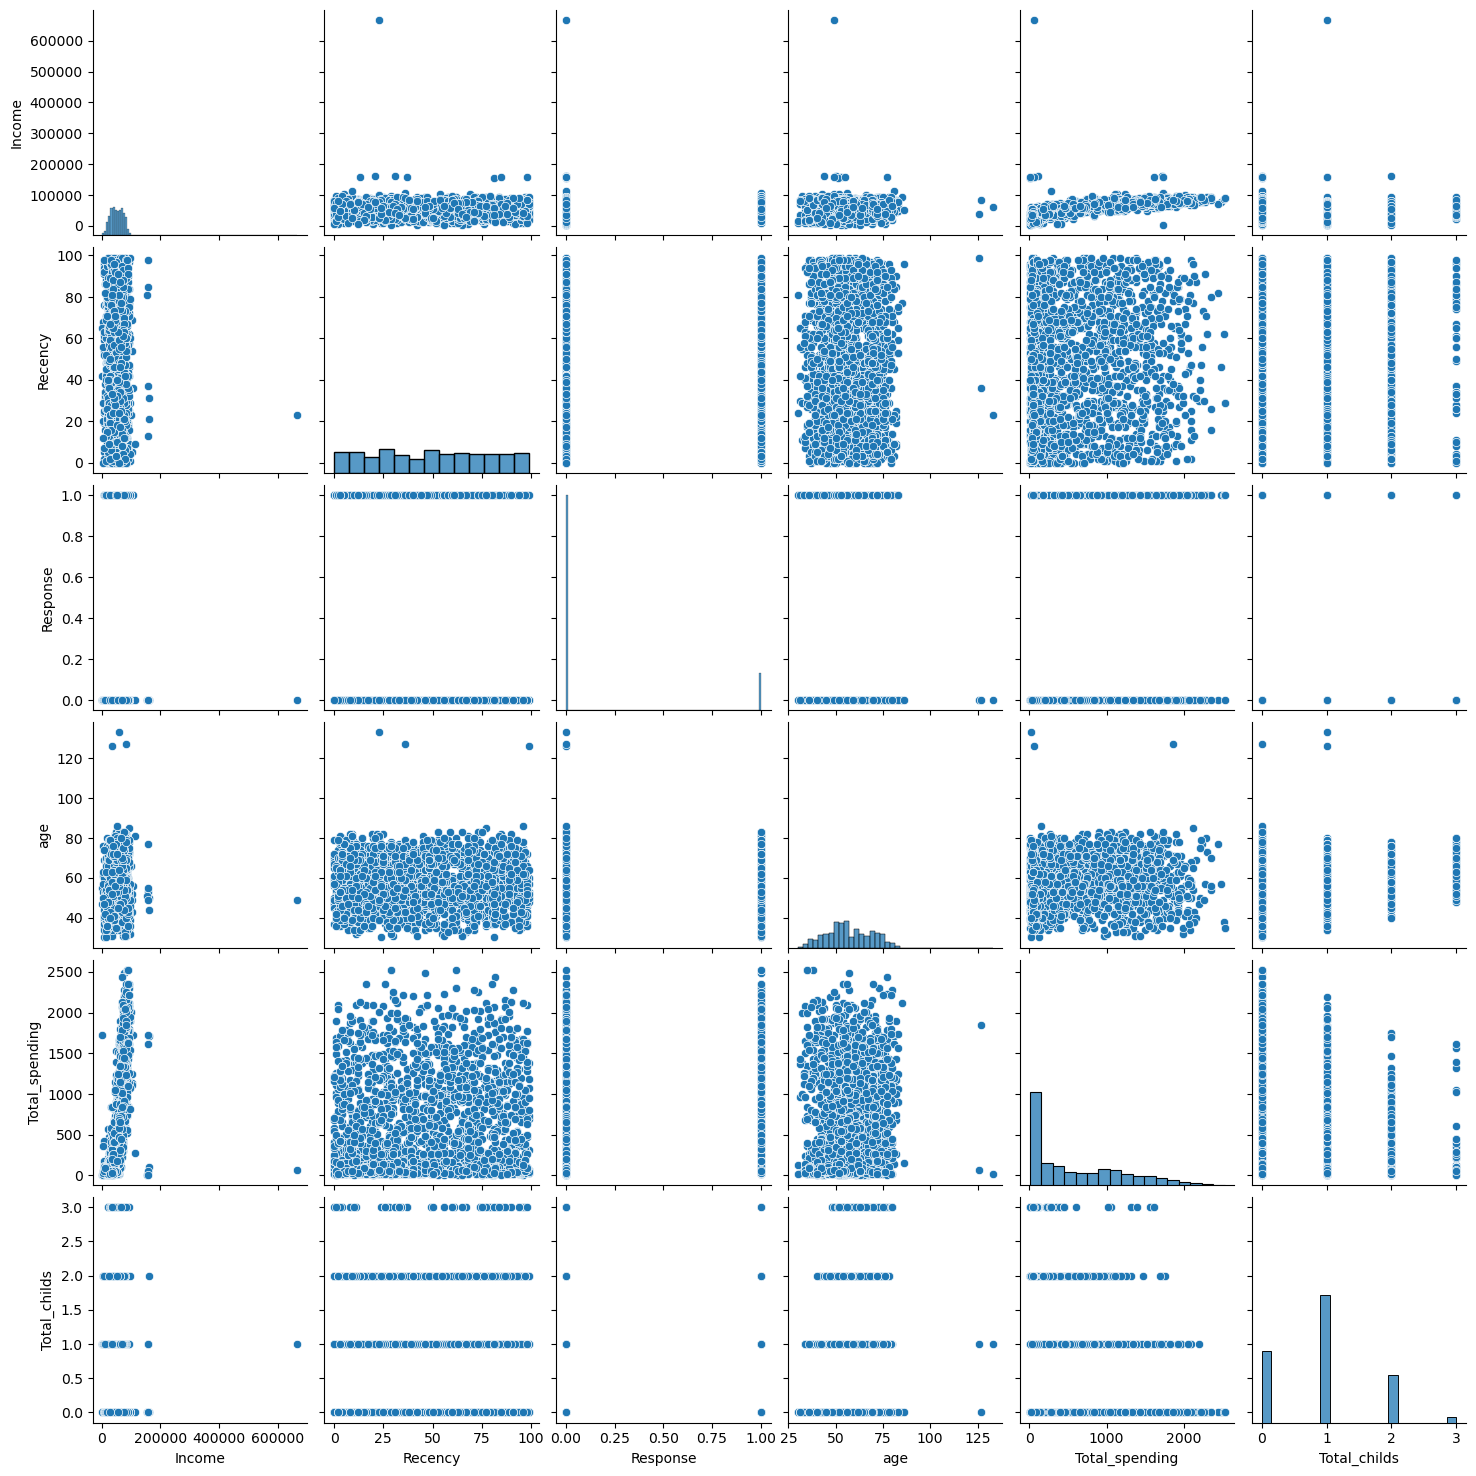

In [16]:
coln =  ["Income", "Recency", "Response", "age", "Total_spending", "Total_childs"]
sns.pairplot(X_clean[coln])

In [34]:
X["Income"] = pd.to_numeric(X["Income"], errors="coerce")
X = X[(X["Income"]<600000)]
X = X[(X["age"]<90)]